In [45]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import equinox as eqx
from flowjax.flows import coupling_flow
from flowjax.distributions import Normal
from flowjax.bijections import Affine, RationalQuadraticSpline

from types import SimpleNamespace

import matplotlib.pyplot as plt


In [46]:
DEFAULT_CONFIG = SimpleNamespace(
    param_dim=2, # how many parameters do we want to infer?
    freqs=jnp.linspace(1e-5, 1e-3, 256)
)
DEFAULT_CONFIG.cond_dim = len(DEFAULT_CONFIG.freqs)

# Build the signal model

In [47]:
def get_noise(freqs, key, noise_level=1.0):
    # DON'T TRY THIS AT HOME
    # usually have real and imaginary part
    noise = jax.random.normal(key, shape=freqs.shape) * noise_level
    return noise

def get_cutoff_freq(mass):
    return 4400 / mass

def get_asd(freqs):
    return freqs ** (- 1)

def get_signal(freqs, precession_amplitude, log10_mass):

    # GW signal
    amplitude = 1e-1
    characteristic_freq = 1e-5
    
    mass = 10 ** log10_mass
    cutoff_freq = get_cutoff_freq(mass=mass)

    signal = freqs ** (-7 / 6) * (
        1 + precession_amplitude * jnp.sin(freqs / characteristic_freq)
    ) * 1 / (1 + jnp.exp((freqs - cutoff_freq)))

    return amplitude * signal

def get_signal_whitened(freqs, precession_amplitude, log10_mass):
    
    asd = get_asd(freqs)
    signal = get_signal(freqs, precession_amplitude, log10_mass)
    
    return signal / asd

(0.0007, np.float64(3.9815047557176717))

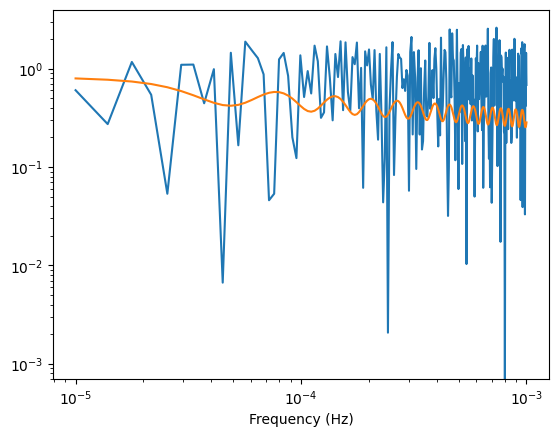

In [48]:
signal = get_signal_whitened(DEFAULT_CONFIG.freqs, precession_amplitude=0.2, log10_mass=jnp.log10(700))
noise = get_noise(DEFAULT_CONFIG.freqs, jax.random.key(2))
data = signal + noise

plt.plot(DEFAULT_CONFIG.freqs, abs(data))
plt.plot(DEFAULT_CONFIG.freqs, signal)
plt.xlabel("Frequency (Hz)")
plt.xscale("log")
plt.yscale("log")
plt.ylim(7e-4, None)

# Prepare data generation

In [49]:
def draw_params_from_prior(key):

    key1, key2 = jax.random.split(key)

    precession_amplitude = jax.random.uniform(key1, shape=(1,), minval=0.001, maxval=0.5)
    log10_mass = jax.random.uniform(key2, shape=(1,), minval=jnp.log10(1e2), maxval=jnp.log10(1e5))

    params = dict(
        precession_amplitude=precession_amplitude,
        log10_mass=log10_mass
    )
    return params

def data_generator(key, config=None):

    if config is None:
        config = DEFAULT_CONFIG

    params = draw_params_from_prior(key)
    
    freqs = config.freqs

    signal = get_signal_whitened(freqs, **params)

    noise_key = jax.random.split(key)[0]
    noise = get_noise(freqs, noise_key)

    data = signal + noise

    params = jnp.concatenate([params['precession_amplitude'], params['log10_mass']])

    return params, data


# Setting up the normalizing flow and associated neural networks

In [50]:
DEFAULT_CONFIG.__dict__.update({
    "flow_layers": 4,
    "nn_width": 64,
    "nn_depth": 4,
})

In [51]:
def construct_flow(config, flow_key):
    return coupling_flow(
        flow_key,
        base_dist=Normal(jnp.zeros(config.param_dim)),
        cond_dim=config.cond_dim,
        transformer=Affine(),
        # transformer=RationalQuadraticSpline(knots=8, interval=(-2, 2)),
        flow_layers=config.flow_layers,
        nn_width=config.nn_width,
        nn_depth=config.nn_depth,
    )

flow_key = jax.random.key(0)
model = construct_flow(DEFAULT_CONFIG, flow_key)

In [52]:
# testing the model
model.log_prob(jnp.zeros(DEFAULT_CONFIG.param_dim), jnp.zeros(DEFAULT_CONFIG.cond_dim))

Array(-1.78520545, dtype=float64)

Let's plot some samples. This should look weird, since the model isn't trained yet. 

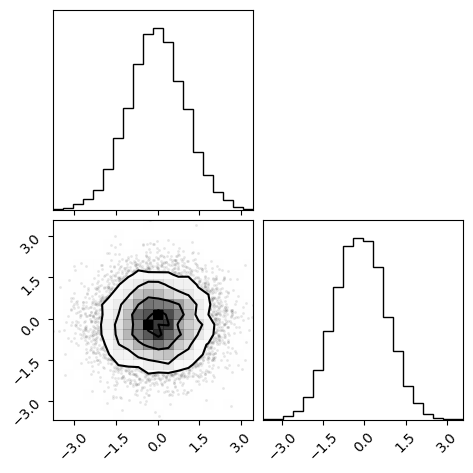

In [53]:
import numpy as np
import corner

samples = model.sample(jax.random.key(1), sample_shape=(10_000,), condition=jnp.zeros(DEFAULT_CONFIG.cond_dim))

corner.corner(np.array(samples));

# Defining the standard SBI loss and training loop

In [54]:
def get_loss(model, params, data):
    log_prob = model.log_prob(params, data)
    return -jnp.mean(log_prob)

@eqx.filter_jit
def train_epoch(model, opt_state, data_generator, key):

    params, data = data_generator(key)

    loss, gradient = eqx.filter_value_and_grad(get_loss)(model, params, data)
    updates, new_opt_state = optimizer.update(gradient, opt_state, eqx.filter(model, eqx.is_inexact_array))

    new_model = eqx.apply_updates(model, updates)

    return new_model, new_opt_state, loss

@eqx.filter_jit
def test_epoch(model, data_generator, key):

    test_key = jax.random.split(key)[0]
    params, data = data_generator(test_key)
    loss = get_loss(model, params, data)
    return loss
    

# Training

100%|██████████| 1000/1000 [00:00<00:00, 1037.48it/s]


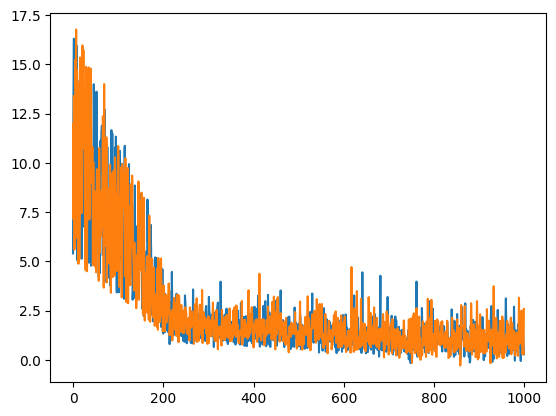

In [55]:
import optax
import tqdm

optimizer = optax.adam(learning_rate=1e-4)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

train_losses = []
test_losses = []

flow_keymodel = construct_flow(DEFAULT_CONFIG, jax.random.key(120))

for i in tqdm.tqdm(range(1000)):
    model, opt_state, loss = train_epoch(model, opt_state, data_generator, jax.random.key(i))
    train_losses.append(loss)

    test_loss = test_epoch(model, data_generator, jax.random.key(i))
    test_losses.append(test_loss)

plt.plot(train_losses)
plt.plot(test_losses)

The loss is very noise. How can we solve this?

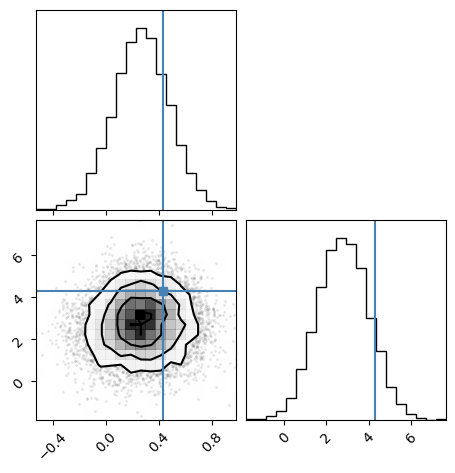

In [56]:
params, data = data_generator(jax.random.key(1))
samples = model.sample(jax.random.key(1), sample_shape=(10_000,), condition=data)

corner.corner(
    np.array(samples),
    truths=np.array(params),
);

In [57]:
@eqx.filter_jit
def train_epoch_batch(model, opt_state, data_generator, key, batch_size=16):
    
    keys = jax.random.split(key, num=batch_size)

    params_batch, data_batch = jax.vmap(data_generator)(keys)

    loss, gradient = eqx.filter_value_and_grad(get_loss)(model, params_batch, data_batch)
    updates, new_opt_state = optimizer.update(gradient, opt_state, eqx.filter(model, eqx.is_inexact_array))

    new_model = eqx.apply_updates(model, updates)

    return new_model, new_opt_state, loss

In [58]:
model = construct_flow(DEFAULT_CONFIG, flow_key)
optimizer = optax.adam(learning_rate=2e-4)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

train_losses = []
test_losses = []
for i in tqdm.tqdm(range(1000)):
    model, opt_state, loss = train_epoch_batch(model, opt_state, data_generator, jax.random.key(i), batch_size=512)
    train_losses.append(loss)

    test_loss = test_epoch(model, data_generator, jax.random.key(i))
    test_losses.append(test_loss)

100%|██████████| 1000/1000 [00:07<00:00, 134.89it/s]


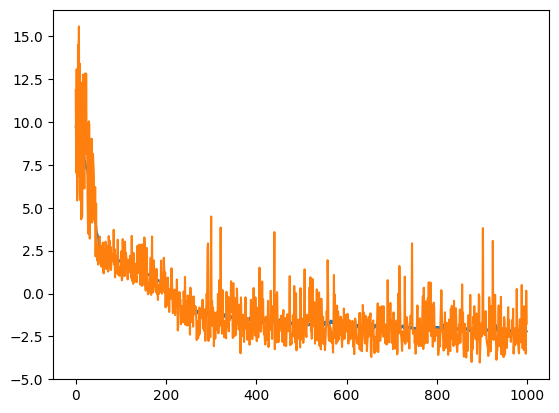

In [59]:
plt.plot(train_losses)
plt.plot(test_losses)

# Inference

Draw random signal and produce posterior samples

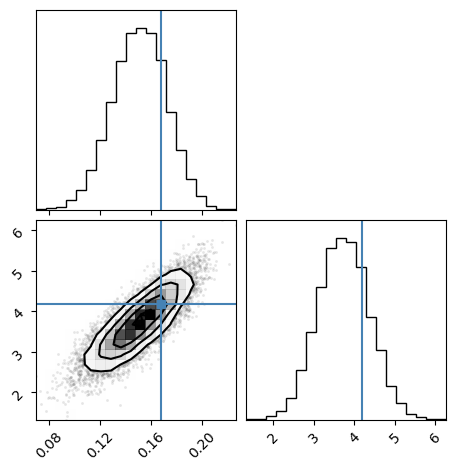

In [63]:
params, data = data_generator(jax.random.key(12120))
true_signal = get_signal_whitened(DEFAULT_CONFIG.freqs, precession_amplitude=params[0], log10_mass=params[1])

samples = model.sample(jax.random.key(1), sample_shape=(10_000,), condition=data)

corner.corner(
    np.array(samples),
    truths=np.array(params),
);

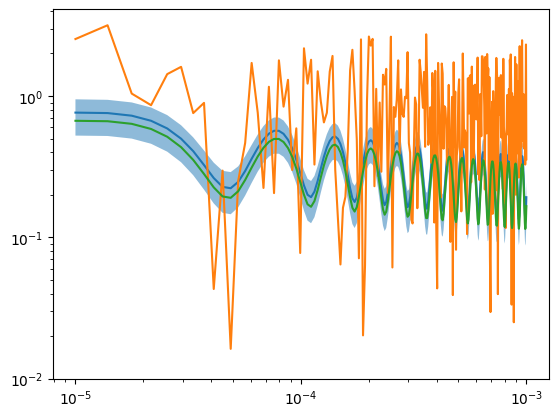

In [61]:
signals = jax.vmap(get_signal_whitened, in_axes=(None, 0, 0))(DEFAULT_CONFIG.freqs, samples[:, 0], samples[:, 1])

perc = jnp.percentile(signals, jnp.array([5, 50, 95]), axis=0)

plt.plot(DEFAULT_CONFIG.freqs, perc[1], label="Median")
plt.fill_between(DEFAULT_CONFIG.freqs, perc[0], perc[2], alpha=0.5, label="90% CI")
plt.plot(DEFAULT_CONFIG.freqs, abs(data))
plt.plot(DEFAULT_CONFIG.freqs, true_signal)
plt.yscale("log")
plt.ylim(1e-2, None)
plt.xscale("log")

In [62]:
# save model parameters
# eqx.tree_serialise_leaves("../models/flow_2D_simple.eqx", model)